<div style="border-radius:10px;overflow:hidden;font-family:Aptos,Calibri,Segoe UI,sans-serif;border:1px solid #e6e9ee">
  <div style="background:#0A2540;padding:18px 22px;color:#fff">
    <div style="font-size:12px;letter-spacing:2px;color:#F4B942;font-weight:700">CARISURG · MEDTECH PATHWAYS · WEEK 5 · TUTORIAL 4</div>
    <div style="font-size:24px;font-weight:700;margin-top:4px">Exploratory Visualisation</div>
    <div style="font-size:14px;color:#cdd6df;margin-top:6px">A data-quality dashboard: missingness, acuity, demographics, complaints, vitals.</div></div>
  <div style="background:#F4B942;color:#0A2540;padding:6px 22px;font-size:12px;font-weight:700;letter-spacing:1px">STUDENT NOTEBOOK</div></div>

## Goal
Build the dashboard the memo needs (the brief asks for **4+ plots**, including **race/ethnicity** and **chief-complaint** views):
1. Missingness (structured, before cleaning) · 2. ESI class balance + age · 3. **Race/ethnicity distribution** ·
4. **Top chief complaints** · 5. Vitals by ESI · 6. Correlation (vitals + ESI) & complaint↔acuity.

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Build the six-plot dashboard yourself. Each plot cell below is a TODO with the exact pandas/matplotlib calls named in its comments — fill them in and save each figure to <code>figs/</code>. By the end you have the 4+ committed figures (including race/ethnicity and chief complaints) the Tutorial 5 memo needs.</div>

## 1 · Setup & load cleaned (rebuilds from raw if needed)

In [1]:
# Run this cell first. These are the three libraries we use all week.
import numpy as np                 # numerical helpers (NaN, medians, etc.)
import pandas as pd                # tables / DataFrames — our main tool
import matplotlib.pyplot as plt    # plotting

# Let pandas show more of a wide table when we print it:
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Environment ready · pandas", pd.__version__)

Environment ready · pandas 2.2.2


In [2]:
# ── Schema map ────────────────────────────────────────────────────────────────
# This dataset has ~225 columns, so we never list them by hand. We sort them into
# "families" once, then refer to the families by name for the rest of the week.

TARGET = "esi"   # Emergency Severity Index: 1 (most urgent) .. 5 (least). Our triage label.

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

def classify_columns(df):
    """Sort the DataFrame's columns into families and return them in a dictionary."""

    # Helper: from a wish-list of names, keep only the ones that really exist in df.
    # (A plain function instead of a lambda, so it is easy to read.)
    def keep_present(wanted):
        present = []
        for col in wanted:
            if col in df.columns:
                present.append(col)
        return present

    # The ~200 chief-complaint columns all start with "cc_", so we find them by prefix:
    chief_complaints = []
    for col in df.columns:
        if col.startswith("cc_"):
            chief_complaints.append(col)

    families = {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }
    return families

In [ ]:
# Reference ranges for general adult triage. Each entry is (low, high, unit).
# NOTE: temperature is in FAHRENHEIT in this dataset (≈98.6 normal), not Celsius!
NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), "triage_glucose": (70,140,"mg/dL")}

# "Plausible" bounds are much wider than normal — anything OUTSIDE these is treated as a
# data error (e.g. a heart rate of 5). Each entry is (low, high).
PLAUSIBLE = {"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_glucose": (20,800)}

In [ ]:
# Clinically meaningful axis/tick labels for plotting (does not change any values,
# only how columns are displayed on charts).
LABELS = {
    "triage_vital_hr":   "Heart rate (bpm)",
    "triage_vital_sbp":  "Systolic BP (mmHg)",
    "triage_vital_dbp":  "Diastolic BP (mmHg)",
    "triage_vital_rr":   "Respiratory rate (breaths/min)",
    "triage_vital_o2":   "SpO2 (%)",
    "triage_vital_temp": "Temperature (°F)",
    "triage_glucose":    "Glucose (mg/dL)",
    "esi":               "ESI (Triage_Level)",
    "age":               "Age (years)",
}


In [ ]:
import os
def clean_triage(raw):
    """Canonical Week-5 cleaning pipeline (the same steps you build in Tutorial 3).
    Takes the raw DataFrame and returns a cleaned copy."""
    d = raw.copy()
    fam = classify_columns(d)

    # 1. Drop rows with no triage label — we cannot learn a decision the data never recorded.
    d = d[d[TARGET].notna()].copy()

    # 2. Make the vital-sign columns (and age) numeric. Any stray text becomes NaN.
    numeric_cols = list(fam["vitals"])          # a copy of the vital-column list
    if "age" in d.columns:
        numeric_cols.append("age")
    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # 3. Flag physiologically impossible values as missing (NaN) — do not "cap" them.
    for col in PLAUSIBLE:
        low, high = PLAUSIBLE[col]
        if col in d.columns:
            out_of_range = (d[col] < low) | (d[col] > high)
            d.loc[out_of_range, col] = np.nan

    # 4. Fill the gaps. Vitals -> median (a robust middle value).
    for col in fam["vitals"]:
        d[col] = d[col].fillna(d[col].median())
    # A blank oxygen-device flag or chief-complaint flag means "not recorded" = 0.
    if "triage_vital_o2_device" in d.columns:
        d["triage_vital_o2_device"] = d["triage_vital_o2_device"].fillna(0)
    for col in fam["chief_complaints"]:
        d[col] = d[col].fillna(0)
    # Text categories: a blank becomes the explicit category "Unknown".
    for col in fam["demographics"] + fam["admin"] + fam["leakage"]:
        if d[col].dtype == object:
            d[col] = d[col].fillna("Unknown")

    # 5. The target should be a whole number 1-5, not a decimal.
    d[TARGET] = d[TARGET].round().astype(int)
    return d

In [8]:
from pathlib import Path
import os # Added import os
CLEAN_PATH, RAW_PATH = Path("triage_cleaned_v1.csv"), Path("yaleemmlc_admissionprediction_triage.csv")
if CLEAN_PATH.exists():
    df = pd.read_csv(CLEAN_PATH); print("Loaded cleaned data from Tutorial 3")
elif RAW_PATH.exists():
    df = clean_triage(pd.read_csv(RAW_PATH, index_col=0)); print("Rebuilt from raw via clean_triage()")
else:
    raise FileNotFoundError("Need triage_cleaned_v1.csv or the raw CSV.")
raw = pd.read_csv(RAW_PATH, index_col=0) if RAW_PATH.exists() else None
fam = classify_columns(df); os.makedirs("figs", exist_ok=True); print(df.shape)

Loaded cleaned data from Tutorial 3
(55121, 225)


In [4]:
from google.colab import files

print("Please upload the missing CSV files (e.g., 'triage_cleaned_v1.csv' or 'yaleemmlc_admissionprediction_triage.csv').")
uploaded = files.upload()

Please upload the missing CSV files (e.g., 'triage_cleaned_v1.csv' or 'yaleemmlc_admissionprediction_triage.csv').


Saving triage_cleaned_v1.csv to triage_cleaned_v1.csv


<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>Path('triage_cleaned_v1.csv').exists()</code> just asks ‘is this file here?’. The cell loads the cleaned file if Tutorial 3 produced it, otherwise rebuilds it from the raw CSV with <code>clean_triage(...)</code> — so the notebook runs even on a fresh machine. <code>index_col=0</code> tells <code>read_csv</code> the first column is the row label, not data.</div>

## 2 · Plot 1 — Missingness before cleaning (structured)

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 1.</b> Show <i>where</i> data is missing before cleaning, as a heatmap of the missing-cell grid. Think: which matplotlib calls turn a True/False grid into a picture and label its columns?</div>

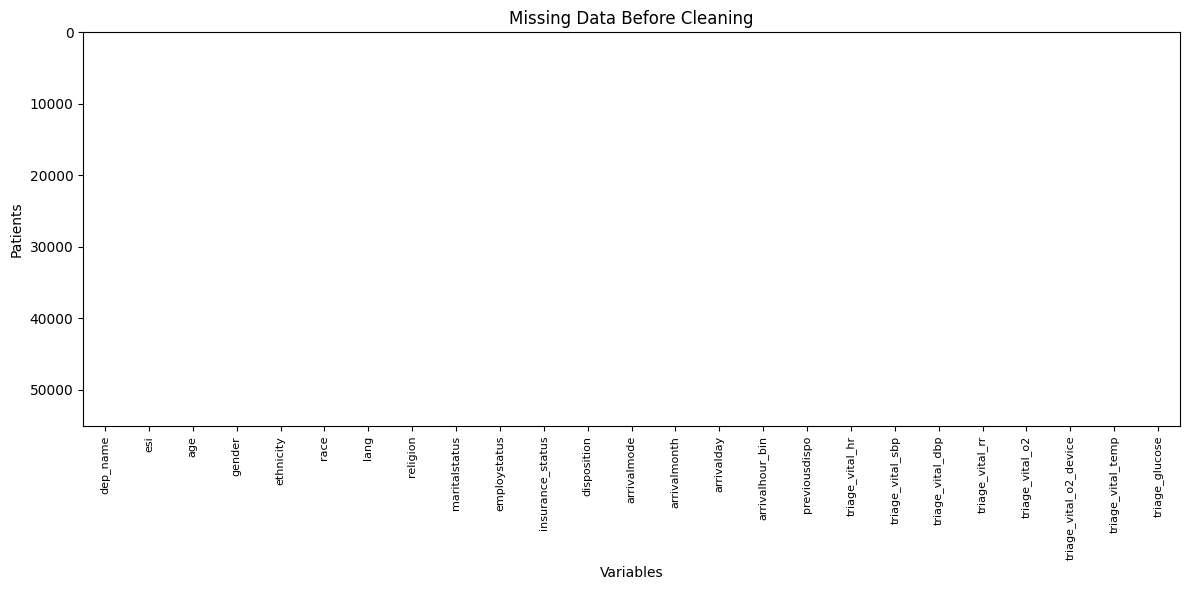

In [9]:
src = (raw if raw is not None else df)
structured = [c for c in src.columns if not c.startswith("cc_")]
# TODO — draw a missingness map of src[structured] and save it.
#  - the missing-cell grid is src[structured].isna().values   (True where missing)
#  - make a figure + axes with plt.subplots(...)
#  - paint the grid with ax.imshow(...); look up the aspect= and cmap= args so missing reads as dark
#  - label the columns with ax.set_xticks(...) and ax.set_xticklabels(...) (rotate them so they fit)
#  - finish: plt.tight_layout(), then plt.savefig("figs/01_missingness.png", dpi=110), then plt.show()

fig, ax = plt.subplots(figsize=(12,6))

ax.imshow(
    src[structured].isna().values,
    aspect="auto",
    cmap="binary"
)

ax.set_title("Missing Data Before Cleaning")
ax.set_xlabel("Variables")
ax.set_ylabel("Patients")

ax.set_xticks(range(len(structured)))
ax.set_xticklabels(structured, rotation=90, fontsize=8)

plt.tight_layout()
plt.savefig("figs/01_missingness.png", dpi=200)
plt.show()


## 3 · Plot 2 — ESI class balance & age

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 2.</b> Two panels in one figure: a <b>bar chart</b> of how many patients sit at each ESI level, and a <b>histogram</b> of age. Decide which matplotlib call draws bars and which draws a histogram.</div>

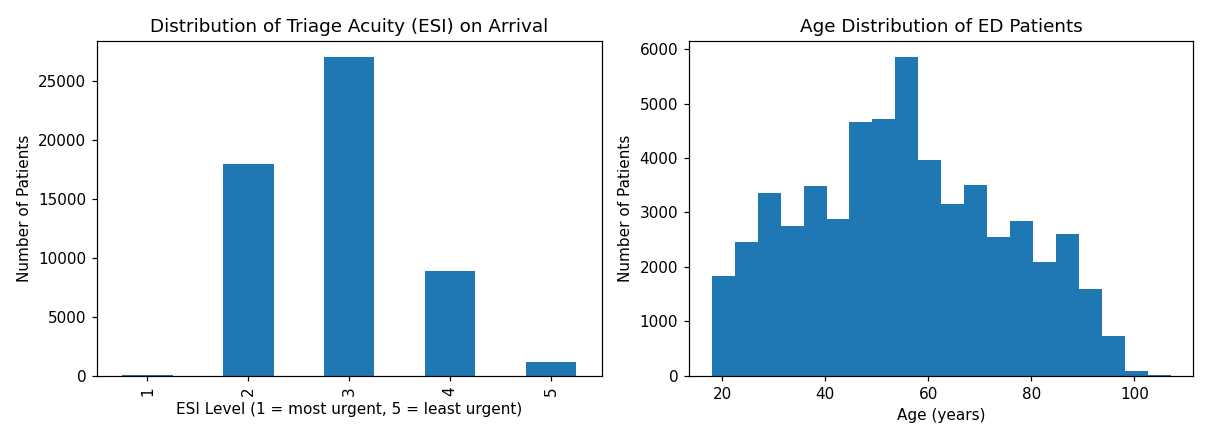

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))

# Left panel — ESI class balance
df[TARGET].value_counts().sort_index().plot.bar(ax=ax[0])
ax[0].set_title("Distribution of Triage Acuity (ESI) on Arrival")
ax[0].set_xlabel("ESI Level (1 = most urgent, 5 = least urgent)")
ax[0].set_ylabel("Number of Patients")

# Right panel — age distribution
ax[1].hist(df["age"], bins=20)
ax[1].set_title("Age Distribution of ED Patients")
ax[1].set_xlabel(LABELS["age"])
ax[1].set_ylabel("Number of Patients")

plt.tight_layout(); plt.savefig("figs/02_esi_age.png", dpi=110); plt.show()

<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>plt.subplots(1, 2, ...)</code> makes a figure with a row of panels; <code>ax[0]</code> and <code>ax[1]</code> are the left and right panels you draw into. And you can plot straight from pandas: <code>some_series.plot.bar(ax=ax[0])</code> draws that Series as bars in a chosen panel — no need to hand matplotlib the x and y separately.</div>

## 4 · Plot 3 — Race & ethnicity (required, and a fairness lens)

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 3 (required).</b> Two horizontal bar charts — the race and ethnicity make-up of the sample. This is the equity view, so the categories must be readable; consider why horizontal bars help here.</div>

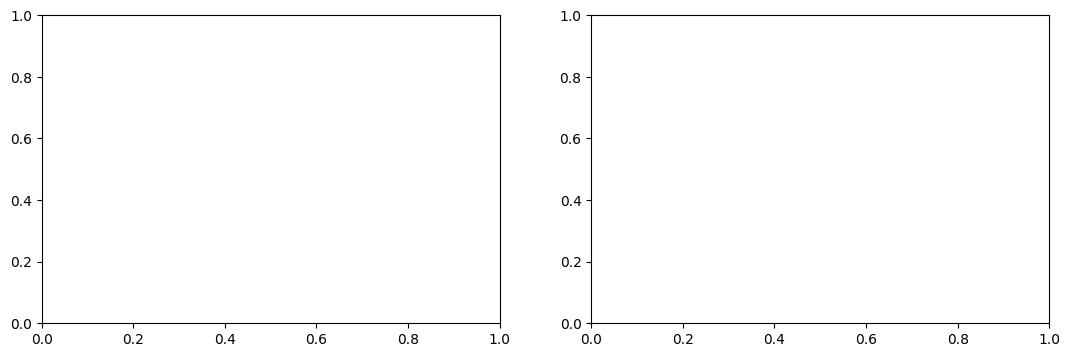

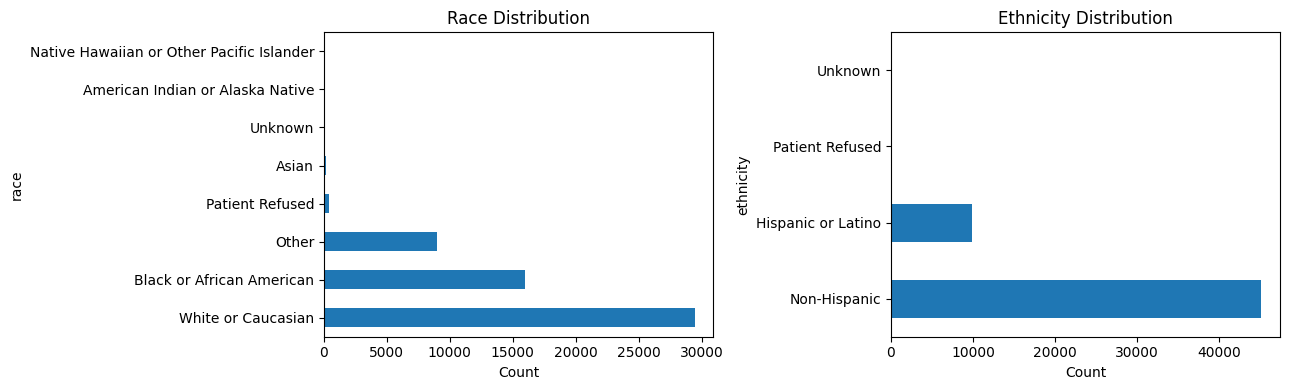

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))
# TODO ax[0] — Race as a HORIZONTAL bar chart:
#   - tally the categories with df["race"].value_counts()
#   - draw it with .plot.barh(ax=ax[0], ...)   (barh = horizontal, good for long labels)
#   - title it with ax[0].set_title(...)
# TODO ax[1] — Ethnicity the same way, drawn into ax[1].

fig, ax = plt.subplots(1,2, figsize=(13,4))

df["race"].value_counts().plot.barh(ax=ax[0])

ax[0].set_title("Race Distribution")
ax[0].set_xlabel("Count")

df["ethnicity"].value_counts().plot.barh(ax=ax[1])

ax[1].set_title("Ethnicity Distribution")
ax[1].set_xlabel("Count")

plt.tight_layout(); plt.savefig("figs/03_demographics.png", dpi=110); plt.show()

<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>df['race'].value_counts()</code> tallies how many patients fall in each category; chaining <code>.plot.barh()</code> draws those tallies as a horizontal bar chart in one line. <code>barh</code> (horizontal) is the friendly choice when category names are long — they read left-to-right instead of overlapping under a vertical axis.</div>

<div style="border-left:4px solid #1B9AAA;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#1B9AAA">🩺 CLINICAL CONTEXT</b><br>Read this plot as an equity check: if one group dominates the sample, a model may underperform for everyone else — and this US sample may look nothing like a Caribbean ED. That sentence belongs in the memo's caveats.</div>

## 5 · Plot 4 — Top chief complaints (required)

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 4 (required).</b> Rank the chief-complaint flags and show the top 15 as a horizontal bar chart, biggest bar on top. Think about how to turn 200 0/1 columns into one count per complaint.</div>

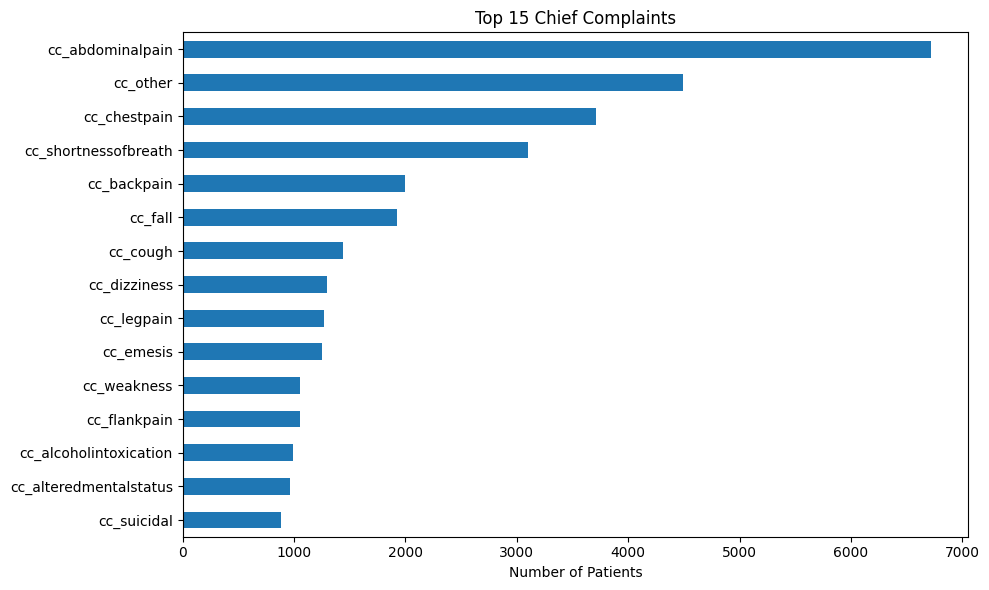

In [ ]:
# TODO — top 15 chief complaints as a horizontal bar chart, biggest bar on top.
#  - count each complaint by summing the 0/1 flags: df[fam["chief_complaints"]].sum()
#  - sort it descending (.sort_values(...)) and keep the top 15 (.head(...))
#  - make the axes with plt.subplots(...)
#  - draw with .plot.barh(...); reverse the order with [::-1] so the biggest bar is on top
#  - title it, then plt.tight_layout() / plt.savefig("figs/04_chief_complaints.png", dpi=110) / plt.show()

complaints = (
    df[fam["chief_complaints"]]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10,6))

complaints[::-1].plot.barh(ax=ax)

ax.set_title("Top 15 Chief Complaints")
ax.set_xlabel("Number of Patients")

plt.tight_layout()
plt.savefig("figs/04_chief_complaints.png", dpi=200)
plt.show()


<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>df[fam['chief_complaints']].sum()</code> counts each complaint (summing 0/1 flags), and <code>.head(15)</code> keeps the 15 biggest after sorting. <code>top15[::-1]</code> is a <b>reverse slice</b> — ‘same items, back to front’ — used so the largest bar lands at the <i>top</i> of a horizontal chart instead of the bottom.</div>

## 6 · Plot 5 — Do vitals separate the ESI classes?

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 5.</b> A 2×3 grid of box-plots — one panel per vital, one box per ESI level — so you can see which vitals separate the acuity classes. Which matplotlib call draws a box-plot from a list of value groups?</div>

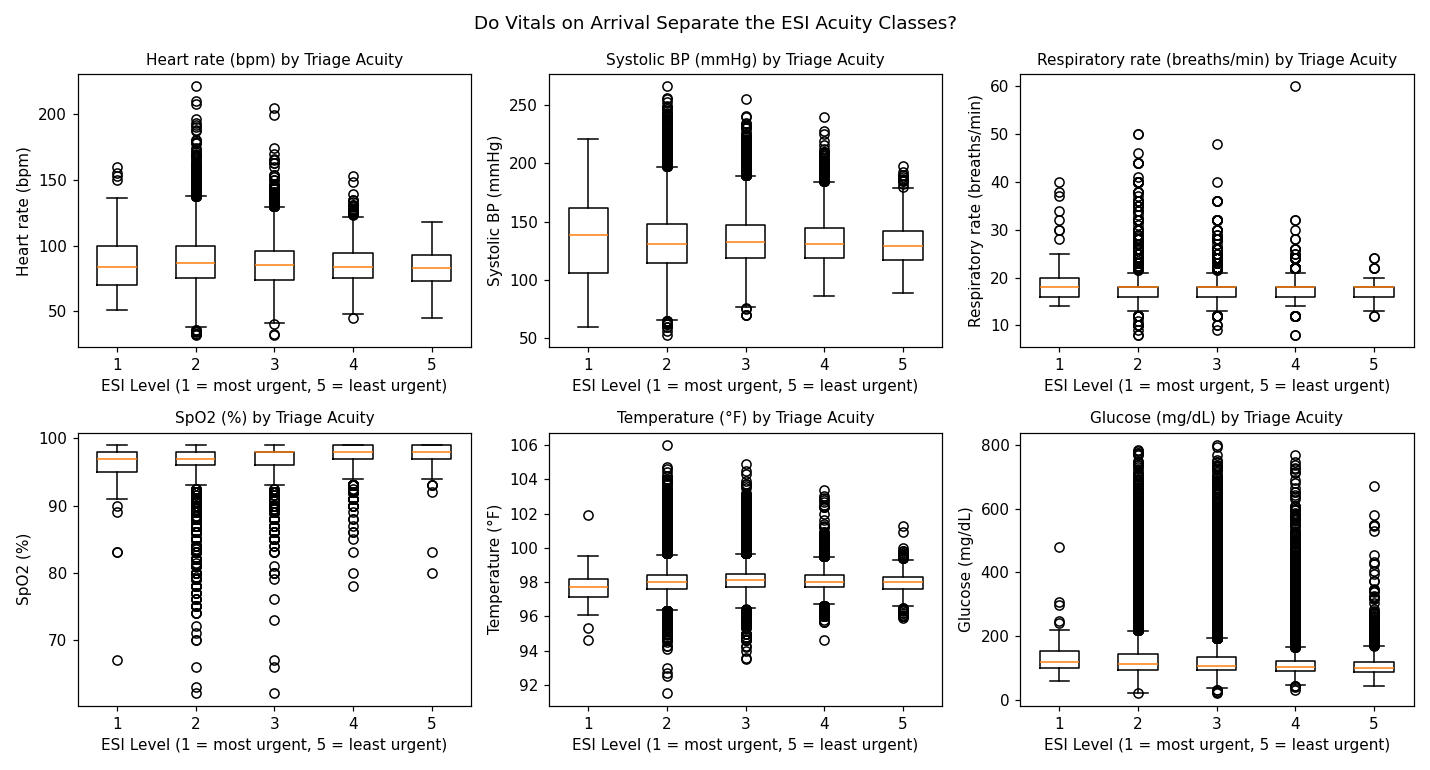

In [ ]:
vitals_to_plot = ["triage_vital_hr","triage_vital_sbp","triage_vital_rr",
                  "triage_vital_o2","triage_vital_temp","triage_glucose"]

esi_levels = sorted(df[TARGET].unique())

fig, axes = plt.subplots(2, 3, figsize=(13,7))

for panel, col in zip(axes.ravel(), vitals_to_plot):

    groups = [
        df.loc[df[TARGET] == level, col].dropna()
        for level in esi_levels
    ]

    panel.boxplot(groups, tick_labels=esi_levels)

    panel.set_title(f"{LABELS[col]} by Triage Acuity", fontsize=10)
    panel.set_xlabel("ESI Level (1 = most urgent, 5 = least urgent)")
    panel.set_ylabel(LABELS[col])

fig.suptitle("Do Vitals on Arrival Separate the ESI Acuity Classes?", fontsize=12)
plt.tight_layout()
plt.savefig("figs/05_vitals_by_esi.png", dpi=110)
plt.show()

<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>df[TARGET] == level</code> is a True/False mask over the rows. <code>df.loc[mask, col]</code> then reads just one column for just the rows where the mask is True — here, that vital’s values for one ESI level. Building one group per level gives the box-plot a separate box per acuity class, so you can <i>see</i> whether the vital separates them.</div>

## 7 · Plot 6 — Correlation (vitals + ESI) and complaint↔acuity

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 6.</b> Draw the vitals+ESI correlation matrix as a colour-coded heatmap with the number written in each cell. Think about the matplotlib calls that paint a grid, write text in a cell, and add a colour scale.</div>

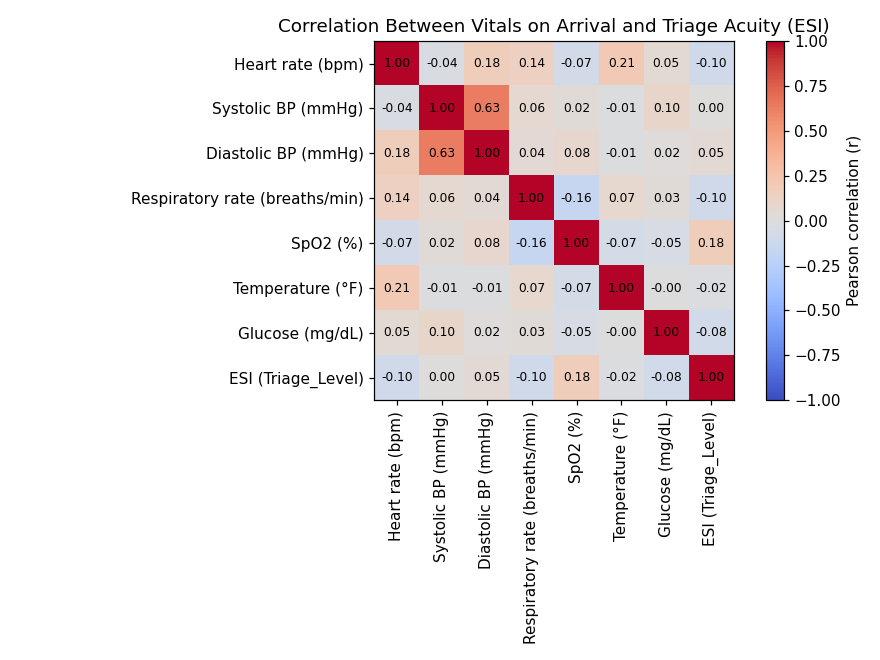

In [ ]:
cols = fam["vitals"] + [TARGET]
corr = df[cols].corr()
cols_labelled = [LABELS.get(c, c) for c in cols]

fig, ax = plt.subplots(figsize=(8,6))

im = ax.imshow(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols_labelled, rotation=90)

ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols_labelled)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

ax.set_title("Correlation Between Vitals on Arrival and Triage Acuity (ESI)")
cbar = fig.colorbar(im)
cbar.set_label("Pearson correlation (r)")

plt.tight_layout()
plt.savefig("figs/06_correlation.png", dpi=200)
plt.show()


<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>df[cols].corr()</code> returns a square table — every column correlated with every other (the diagonal is always 1). <code>corr.iloc[i, j]</code> reads a cell by <b>position</b> (row number i, column number j), which is why the double loop can write each number onto the heatmap. <code>imshow</code> just paints that table as coloured squares.</div>

## 8 · Exercises
1. Complete all six plots and save them to `figs/`.
2. Which vital separates the ESI classes best? Worst? One sentence each.
3. Cross-tabulate `cc_chestpain` against ESI — does it skew urgent as expected?
4. Add one equity plot: ESI distribution *within* each race category. What would worry a clinician?

## 9 · Wrap-up
Six committed figures. **Next — Tutorial 5: the Feasibility Memo.**